In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print("Features Shape:", X.shape)
print("Labels Shape:", y.shape)

Features Shape: (150, 4)
Labels Shape: (150,)


In [3]:
df = pd.DataFrame(X, columns=iris.feature_names)
df["Species"] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
y = to_categorical(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


In [5]:
def create_model(learning_rate):

    model = Sequential([
        Dense(16, activation='relu', input_shape=(4,)),
        Dense(8, activation='relu'),
        Dense(3, activation='softmax')
    ])

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [6]:
model = create_model(0.01)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
3/3 [==============================] - 1s 102ms/step - loss: 1.1738 - accuracy: 0.3125 - val_loss: 1.0783 - val_accuracy: 0.4583
Epoch 2/50
3/3 [==============================] - 0s 14ms/step - loss: 0.9365 - accuracy: 0.6354 - val_loss: 0.9530 - val_accuracy: 0.4583
Epoch 3/50
3/3 [==============================] - 0s 15ms/step - loss: 0.7981 - accuracy: 0.6562 - val_loss: 0.8905 - val_accuracy: 0.4583
Epoch 4/50
3/3 [==============================] - 0s 14ms/step - loss: 0.7115 - accuracy: 0.7292 - val_loss: 0.8607 - val_accuracy: 0.5833
Epoch 5/50
3/3 [==============================] - 0s 14ms/step - loss: 0.6658 - accuracy: 0.7604 - val_loss: 0.8382 - val_accuracy: 0.5833
Epoch 6/50
3/3 [==============================] - 0s 15ms/step - loss: 0.6337 - accuracy: 0.7604 - val_loss: 0.8209 - val_accuracy: 0.5417
Epoch 7/50
3/3 [==============================] - 0s 15ms/step - loss: 0.6066 - accuracy: 0.7500 - val_loss: 0.7982 - val_accuracy: 0.5000
Epoch 8/50
3/3 [==========

In [7]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

1/1 [==============================] - 0s 24ms/step - loss: 0.0324 - accuracy: 1.0000
Test Loss: 0.032351210713386536
Test Accuracy: 1.0


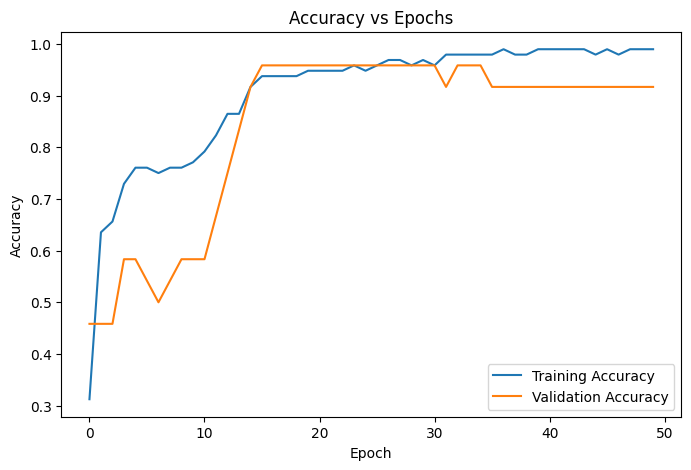

In [8]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")

plt.legend()

plt.show()

In [9]:
learning_rates = [0.1, 0.01, 0.001]

results = []

for lr in learning_rates:

    model = create_model(lr)

    history = model.fit(
        X_train,
        y_train,
        epochs=50,
        validation_split=0.2,
        verbose=0
    )

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    results.append([lr, accuracy])

results_df = pd.DataFrame(
    results,
    columns=["Learning Rate", "Accuracy"]
)

results_df

,Learning Rate,Accuracy
0,0.100,1.0
1,0.010,1.0
2,0.001,0.7


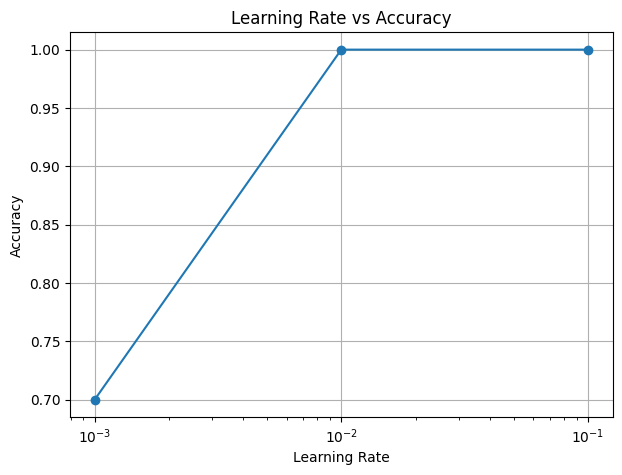

In [10]:
plt.figure(figsize=(7,5))

plt.plot(
    results_df["Learning Rate"],
    results_df["Accuracy"],
    marker='o'
)

plt.xscale("log")

plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")

plt.title("Learning Rate vs Accuracy")

plt.grid(True)

plt.show()

In [11]:
epochs_list = [10, 50, 100]

epoch_results = []

for ep in epochs_list:

    model = create_model(0.01)

    model.fit(
        X_train,
        y_train,
        epochs=ep,
        validation_split=0.2,
        verbose=0
    )

    loss, accuracy = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    epoch_results.append([ep, accuracy])

epoch_df = pd.DataFrame(
    epoch_results,
    columns=["Epochs", "Accuracy"]
)

epoch_df

,Epochs,Accuracy
0,10,0.966667
1,50,0.966667
2,100,1.000000


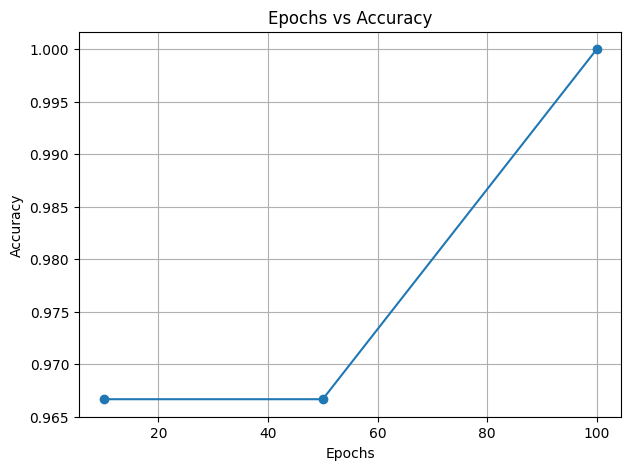

In [12]:
plt.figure(figsize=(7,5))

plt.plot(
    epoch_df["Epochs"],
    epoch_df["Accuracy"],
    marker='o'
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.title("Epochs vs Accuracy")

plt.grid(True)

plt.show()

In [13]:
print("Conclusion")
print("- Forward propagation is performed through Dense layers.")
print("- Backpropagation updates the weights during training.")
print("- Learning rate affects the speed and stability of convergence.")
print("- Too high learning rate may overshoot the optimum.")
print("- Too low learning rate converges slowly.")
print("- Increasing epochs generally improves accuracy until convergence.")

Conclusion
- Forward propagation is performed through Dense layers.
- Backpropagation updates the weights during training.
- Learning rate affects the speed and stability of convergence.
- Too high learning rate may overshoot the optimum.
- Too low learning rate converges slowly.
- Increasing epochs generally improves accuracy until convergence.
